In [1]:
# %%
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import yaml
import warnings
from datetime import datetime

# Add src directory to path
sys.path.append('../src')

# Import custom modules
from data_preprocessing import EthiopianProductPreprocessor
from model_training import EthiopianRecommenderModel
from recommender import EthiopianEcommerceRecommender
from evaluation import RecommenderEvaluator
# Suppress warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [ ]:
# %%
# Load configuration
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("📋 Configuration loaded:")
print(f"Project: {config['project']['name']}")
print(f"Dataset: {config['data']['raw_path']}")
print(f"Text columns: {config['features']['text_columns']}")



📋 Configuration loaded:
Project: Ethiopian E-commerce Product Recommender
Dataset: ../data/raw/ethiopian_products_150k.csv
Text columns: ['name', 'description', 'description_amharic', 'category', 'subcategory', 'brand', 'tags']


In [3]:
model = EthiopianRecommenderModel()

preprocessor = EthiopianProductPreprocessor('../config.yaml')
df_processed = preprocessor.load_processed_data(config['data']['processed_path'])
model.df = df_processed

Loaded processed data from ../data/processed/processed_products.pkl


In [4]:
# %%
# Load raw data for exploration
print("📊 Loading raw dataset for exploration...")
raw_data_path = config['data']['raw_path']

if not os.path.exists(raw_data_path):
    print(f"❌ Dataset not found at: {raw_data_path}")
    print("Please generate the dataset first using generate_dataset.py")
else:
    df_raw = pd.read_csv(raw_data_path)
    print(f"✅ Loaded {len(df_raw):,} products")
    
    # Display basic info
    print("\n📈 Dataset Info:")
    print(f"Shape: {df_raw.shape}")
    print(f"Columns: {df_raw.columns.tolist()}")
    

📊 Loading raw dataset for exploration...
✅ Loaded 150,000 products

📈 Dataset Info:
Shape: (150000, 21)
Columns: ['product_id', 'name', 'name_amharic', 'description', 'description_amharic', 'category', 'subcategory', 'price', 'currency', 'brand', 'location', 'delivery_available', 'rating', 'stock_status', 'stock_quantity', 'weight_kg', 'dimensions', 'warranty_months', 'seller_name', 'seller_rating', 'tags']


In [5]:
model.prepare_features()
model.train()
model.save_model(config['model']['tfidf_path'])

metrics = model.evaluate_model(sample_size=50)

if len(model.df) > 0:
    test_product = model.df.iloc[0]['product_id']
    test_name = model.df.iloc[0]['name']
    print(f"\nGetting recommendations for: {test_name} ({test_product})")
    recommendations = model.get_recommendations(test_product, top_n=3)
    for i, rec in enumerate(recommendations, 1):
        print(f"\n{i}. {rec['name']}")
        print(f"   Category: {rec['category']}")
        print(f"   Price: {rec['price']:,.0f} ETB")
        print(f"   Rating: {rec['rating']:.1f}/5.0")
        print(f"   Similarity Score: {rec['similarity_score']:.3f}")

print("\n" + "="*60)
print("✅ MODEL TRAINING COMPLETE")
print("="*60)


Preparing features...
Training model on 150000 products...
Training content-based model with TF-IDF...
Using on-demand content similarity (no full matrix).
Training category-based model...
Using rule-based category scores (no matrix).
Training price-based model...
Calculating popularity scores...
✅ Model training complete!
✅ Model saved successfully to ../data/models/content_based_model.pkl

📊 CONTENT-BASED MODEL EVALUATION
Testing on 50 products...

📈 EVALUATION RESULTS:
----------------------------------------
• Catalog Coverage: 0.2% of products recommended
• Category Match Rate: 100.0%
• Price Compatibility: 87.6%
• Unique Recommended: 250 products

📊 OVERALL SCORE: 62.6/100
⚠️ GOOD: Model is performing adequately.

Getting recommendations for: ethio coffee beverages premium (ETP00001)

1. Ethio Coffee Beverages Premium early
   Category: Food & Beverages
   Price: 1,600 ETB
   Rating: 4.5/5.0
   Similarity Score: 1.009

2. Ethio Coffee Beverages Premium
   Category: Food & Beverag

In [6]:
print("="*60)
print("🛍️ ETHIOPIAN E-COMMERCE RECOMMENDER SYSTEM")
print("="*60)

# Initialize the recommender
recommender = EthiopianEcommerceRecommender()

# Get system statistics
print("\n📊 SYSTEM STATISTICS:")
print("-"*40)
stats = recommender.get_stats()
print(f"• Total Products: {stats['total_products']:,}")
print(f"• Categories: {stats['categories']}")
print(f"• Average Price: {stats['average_price']:,.0f} ETB")
print(f"• Average Rating: {stats['average_rating']:.1f}/5.0")
print(f"• Model Type: {stats['model_type']}")
print(f"• Algorithm: {stats['algorithm']}")

# Get available categories
print("\n📂 AVAILABLE CATEGORIES:")
print("-"*40)
categories = recommender.get_product_categories()
for i, category in enumerate(categories[:10], 1):
    print(f"{i}. {category}")
if len(categories) > 10:
    print(f"... and {len(categories) - 10} more")

# Test recommendations
print("\n🧪 TESTING RECOMMENDATIONS:")
print("-"*40)

if stats['total_products'] > 0:
    # Get first product for testing
    test_product_id = recommender.model.df.iloc[0]['product_id']
    test_product_name = recommender.model.df.iloc[0]['name']
    
    print(f"\n1. Content-based recommendations for:")
    print(f"   Product: {test_product_name}")
    print(f"   ID: {test_product_id}")
    
    # Get content-based recommendations
    recommendations = recommender.recommend_by_product(
        test_product_id,
        user_context={
            'top_n': 3,
            'diversify': True
        }
    )
    
    for i, rec in enumerate(recommendations['recommendations'], 1):
        print(f"\n   {i}. {rec['name']}")
        print(f"      Category: {rec['category']}")
        print(f"      Price: {rec['price']:,.0f} ETB")
        print(f"      Rating: {rec['rating']:.1f}/5.0")
        print(f"      Similarity: {rec['similarity_score']:.3f}")
    
    # Test category-based recommendations
    if categories:
        print(f"\n2. Category-based recommendations (Fashion):")
        category_recs = recommender.recommend_by_category('Fashion', {'top_n': 2})
        if 'recommendations' in category_recs:
            for i, rec in enumerate(category_recs['recommendations'], 1):
                print(f"   {i}. {rec['name']}")
                print(f"      Price: {rec['price']:,.0f} ETB | Popularity: {rec['popularity_score']:.3f}")
    
    # Test text search
    print(f"\n3. Text search recommendations (search: 'coffee'):")
    search_recs = recommender.recommend_by_text_search('coffee', {'top_n': 2})
    if 'recommendations' in search_recs:
        for i, rec in enumerate(search_recs['recommendations'], 1):
            print(f"   {i}. {rec['name']}")
            print(f"      Category: {rec['category']}")
            print(f"      Similarity: {rec['similarity_score']:.3f}")

print("\n" + "="*60)
print("✅ RECOMMENDER SYSTEM READY")
print("="*60)

🛍️ ETHIOPIAN E-COMMERCE RECOMMENDER SYSTEM
✅ Model loaded successfully
✅ Model loaded successfully

📊 SYSTEM STATISTICS:
----------------------------------------
• Total Products: 150,000
• Categories: 10
• Average Price: 10,031 ETB
• Average Rating: 3.7/5.0
• Model Type: content_based_unsupervised
• Algorithm: TF-IDF + Cosine Similarity

📂 AVAILABLE CATEGORIES:
----------------------------------------
1. Automotive
2. Baby & Kids
3. Beauty & Personal Care
4. Books & Stationery
5. Electronics
6. Fashion
7. Food & Beverages
8. Health
9. Home & Kitchen
10. Sports

🧪 TESTING RECOMMENDATIONS:
----------------------------------------

1. Content-based recommendations for:
   Product: ethio coffee beverages premium
   ID: ETP00001

   1. ETHIO COFFEE BEVERAGES PREMIUM
      Category: Food & Beverages
      Price: 1,600 ETB
      Rating: 3.7/5.0
      Similarity: 1.018

   2. Ethio Coffee Beverages Premium early
      Category: Food & Beverages
      Price: 1,600 ETB
      Rating: 4.5/5.0
   

Evaluation Report:
Catalog Coverage: 0.07%

Category Similarity Analysis:
            categories  intra_similarity                                                                                                                                               sample_products
      Food & Beverages          0.239057                          [{'product_id': 'ETP00001', 'name': 'ethio coffee beverages premium'}, {'product_id': 'ETP00005', 'name': 'tomoca herbal tea 250g'}]
           Electronics          0.148663                                        [{'product_id': 'ETP00002', 'name': 'asus 50" uhd tv'}, {'product_id': 'ETP00006', 'name': 'Xiaomi Mi 12 civil true'}]
            Automotive          0.232439                          [{'product_id': 'ETP00003', 'name': 'auto addis tools deluxe'}, {'product_id': 'ETP00014', 'name': 'MEKINA PARTS CAR CARE PREMIUM'}]
                Sports          0.220731 [{'product_id': 'ETP00004', 'name': 'ETHIO SPORTS FITNESS PROFESSIONAL'}, {'product_id': 

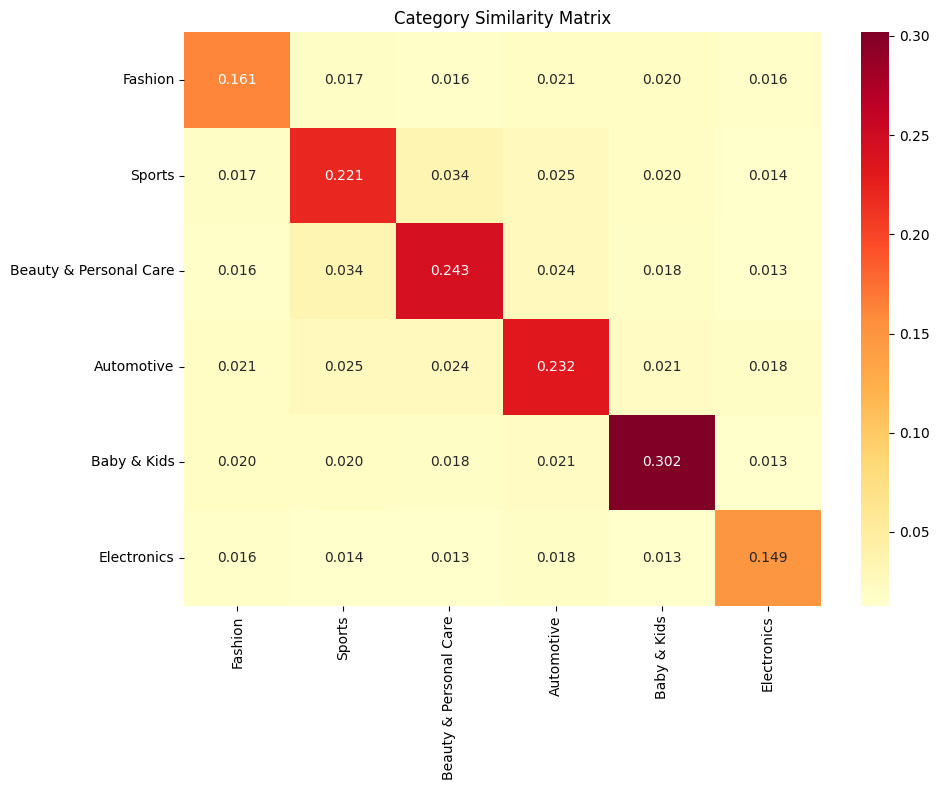

array([[0.161368  , 0.0173946 , 0.01605799, 0.02053167, 0.02015316,
        0.01576099],
       [0.0173946 , 0.22073122, 0.03370964, 0.02481429, 0.01961288,
        0.0136999 ],
       [0.01605799, 0.03370964, 0.2430023 , 0.02418467, 0.01766198,
        0.01273285],
       [0.02053167, 0.02481429, 0.02418467, 0.23243903, 0.02099331,
        0.01754921],
       [0.02015316, 0.01961288, 0.01766198, 0.02099331, 0.30184046,
        0.01275019],
       [0.01576099, 0.0136999 , 0.01273285, 0.01754921, 0.01275019,
        0.14866271]])

In [7]:
evaluator = RecommenderEvaluator(recommender)
    
print("Evaluation Report:")
print("=" * 50)

# Calculate coverage
coverage = evaluator.calculate_coverage()
print(f"Catalog Coverage: {coverage:.2%}")

# Generate similarity report
report = evaluator.generate_similarity_report()
print("\nCategory Similarity Analysis:")
print(report.to_string(index=False))

# Plot heatmap
print("\nGenerating similarity heatmap...")
evaluator.plot_similarity_heatmap()

In [17]:

print("🚀 Quick Demo Interface")

# Simple interactive demo
def interactive_demo():
    print("\n" + "=" * 50)
    print("INTERACTIVE DEMO")
    print("=" * 50)

    # Show sample products
    print("\n📦 Sample Products:")
    sample_products = model.df.sample(5, random_state=42)[['product_id', 'name', 'category', 'price']]
    for idx, row in sample_products.iterrows():
        print(f"{row['product_id']}: {row['name'][:40]}... ({row['category']}) - {row['price']:,} ETB")

    while True:
        print("\n" + "-" * 50)
        print("Options:")
        print("1. Get recommendations for a product ID")
        print("2. Search for products")
        print("3. Exit")

        choice = input("\nEnter your choice (1-3): ").strip()

        if choice == '1':
            product_id = input("Enter product ID (e.g., ETP00001): ").strip()
            if product_id in model.df['product_id'].values:
                top_n = int(input("Number of recommendations (default 5): ") or "5")

                print(f"\n🔍 Recommendations for {product_id}:")
                product_name = model.df[model.df['product_id'] == product_id].iloc[0]['name']
                print(f"Product: {product_name}")

                # Use the recommender's get_recommendations method
                recommendations = model.get_recommendations(
                    product_id=product_id,
                    top_n=top_n,
                    diversify=True
                )

                if recommendations:
                    for i, rec in enumerate(recommendations, 1):
                        print(f"\n{i}. {rec['name']}")
                        print(f"   Price: {rec['price']:,} ETB | Rating: {rec['rating']:.1f}")
                        print(f"   Similarity: {rec.get('similarity_score', 0):.3f}")
                        print(f"   Delivery: {rec.get('delivery_available', 'Unknown')} | Location: {rec.get('location', 'Unknown')}")
                        print(f"   Category: {rec.get('category', 'N/A')}")
                else:
                    print("No recommendations found")
            else:
                print(f"Product ID {product_id} not found")

        elif choice == '2':
            search_text = input("Enter search text: ").strip()
            top_n = int(input("Number of results (default 5): ") or "5")

            print(f"\n🔍 Search results for '{search_text}':")

            # Simple search
            search_results = []
            for idx, row in model.df.iterrows():
                if search_text.lower() in str(row['name']).lower() or \
                   search_text.lower() in str(row.get('description', '')).lower() or \
                   search_text.lower() in str(row.get('category', '')).lower():
                    search_results.append(row)
                    if len(search_results) >= top_n:
                        break

            if search_results:
                for i, row in enumerate(search_results, 1):
                    print(f"\n{i}. {row['name']}")
                    print(f"   Product ID: {row['product_id']}")
                    print(f"   Price: {row['price']:,} ETB | Rating: {row.get('rating', 'N/A')}")
                    print(f"   Category: {row.get('category', 'N/A')}")
            else:
                print("No products found")

        elif choice == '3':
            print("Exiting demo...")
            break
        else:
            print("Invalid choice. Please try again.")

# Run interactive demo if desired
run_demo = input("\nRun interactive demo? (y/n): ").strip().lower()
if run_demo == 'y':
    interactive_demo()

# %%
print("🌐 Preparing Model for Web Application...")

# Verify model files exist
model_files = [
    '../data/models/content_based_model.pkl',
    '../data/processed/processed_products.pkl'
]

print("\n✅ Model Files:")
for file in model_files:
    if os.path.exists(file):
        print(f"   ✓ {file}")
    else:
        print(f"   ✗ {file} (missing)")

print("\n🎉 Demo completed successfully!")

🚀 Quick Demo Interface

INTERACTIVE DEMO

📦 Sample Products:
ETP59771: BABY ETHIOPIA FEEDING STANDARD... (Baby & Kids) - 4,700 ETB
ETP21363: MamaCare Clothing Standard risk road... (Baby & Kids) - 2,100 ETB
ETP127325: Altitude Gear Equipment Professional... (Sports) - 5,800 ETB
ETP140510: Ethio-Sports-Sportswear-Deluxe... (Sports) - 3,100 ETB
ETP144298: Ethio-Sports-Equipment-Premium... (Sports) - 6,900 ETB

--------------------------------------------------
Options:
1. Get recommendations for a product ID
2. Search for products
3. Exit

🔍 Search results for 'Trousers':
No products found

--------------------------------------------------
Options:
1. Get recommendations for a product ID
2. Search for products
3. Exit

🔍 Search results for 'T-shirt':

1. Lucy Fashion T-Shirt
   Product ID: ETP00119
   Price: 2,700 ETB | Rating: 4.0
   Category: Fashion

2. HABESHA DESIGN T-SHIRT
   Product ID: ETP00133
   Price: 7,100 ETB | Rating: 4.0
   Category: Fashion

3. Lucy-Fashion-T-Shirt
   Pr

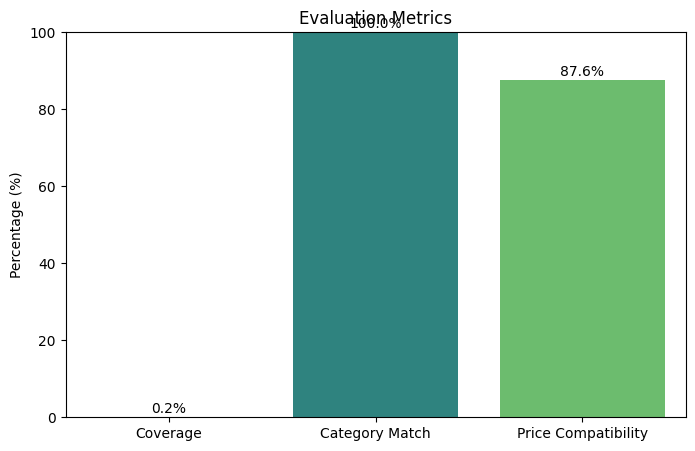

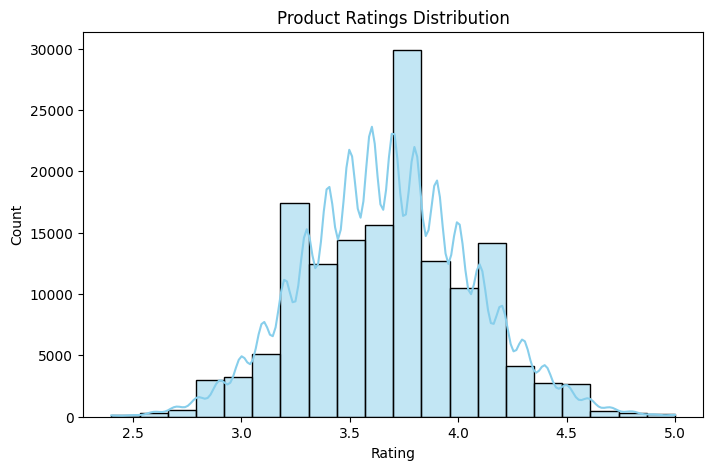

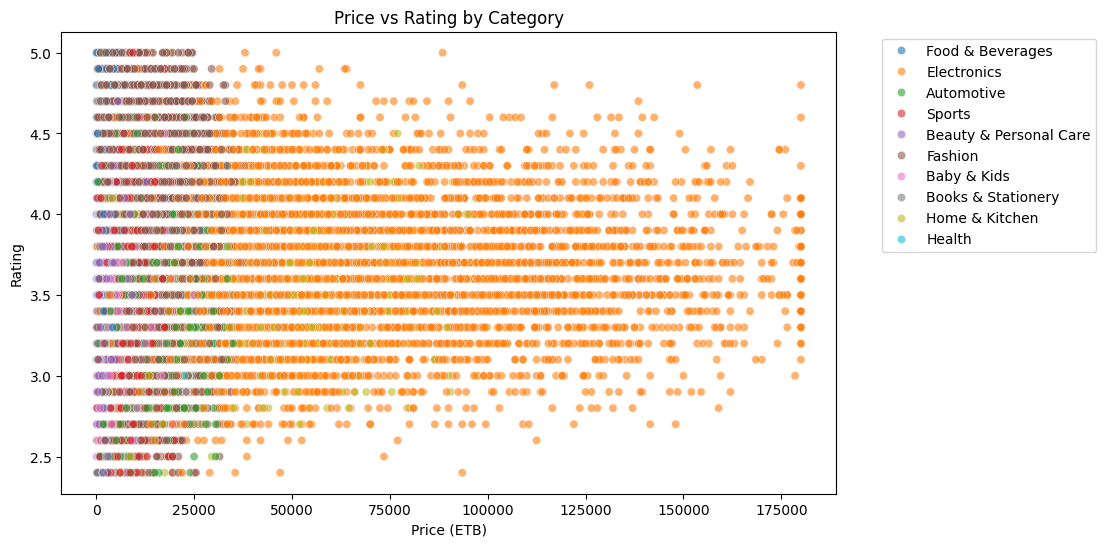

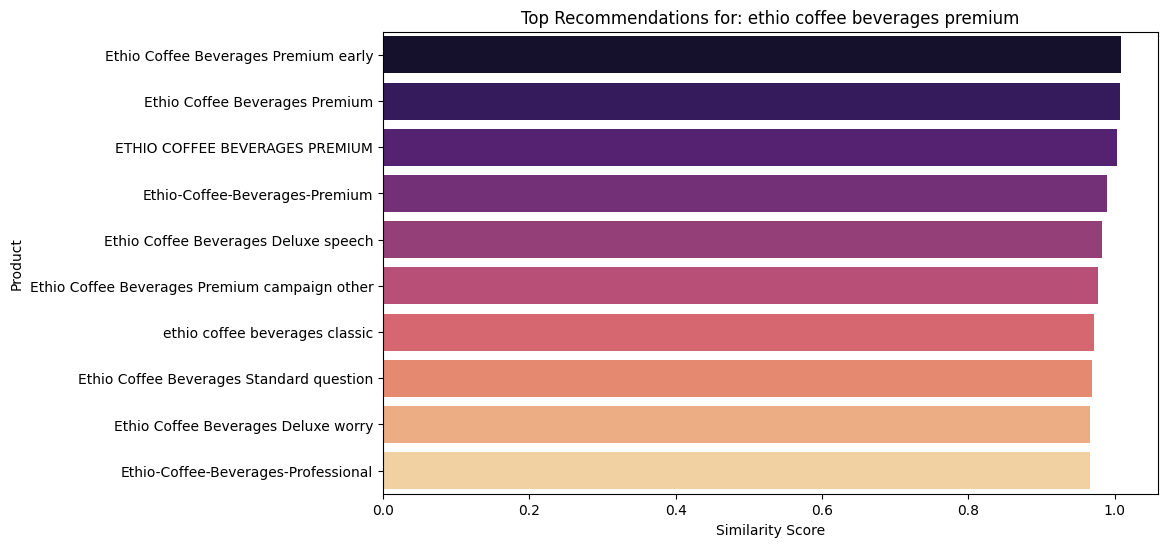

In [ ]:
# 1. Bar chart of evaluation metrics
def plot_evaluation_metrics(metrics):
    labels = ['Coverage', 'Category Match', 'Price Compatibility']
    values = [metrics['coverage'], metrics['category_match'], metrics['price_compatibility']]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=labels, y=values, palette='viridis')
    plt.title("Evaluation Metrics")
    plt.ylabel("Percentage (%)")
    plt.ylim(0, 100)
    for i, v in enumerate(values):
        plt.text(i, v + 1, f"{v:.1f}%", ha='center')
    plt.show()

# 2. Histogram of product ratings
def plot_rating_distribution(df):
    plt.figure(figsize=(8, 5))
    sns.histplot(df['rating'], bins=20, kde=True, color='skyblue')
    plt.title("Product Ratings Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.show()

# 3. Scatter plot of price vs rating, colored by category
def plot_price_vs_rating(df):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='price', y='rating', hue='category', alpha=0.6)
    plt.title("Price vs Rating by Category")
    plt.xlabel("Price (ETB)")
    plt.ylabel("Rating")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# 4. Horizontal bar chart of top recommendations
def plot_recommendations(recommendations, query_name):
    recs_df = pd.DataFrame(recommendations[:10])  # top 10
    plt.figure(figsize=(10, 6))
    sns.barplot(data=recs_df, x='similarity_score', y='name', palette='magma')
    plt.title(f"Top Recommendations for: {query_name}")
    plt.xlabel("Similarity Score")
    plt.ylabel("Product")
    plt.show()

# Plot evaluation metrics
plot_evaluation_metrics(metrics)

# Plot rating distribution
plot_rating_distribution(model.df)

# Plot price vs rating
plot_price_vs_rating(model.df)

# Plot recommendations for a sample product
if len(model.df) > 0:
    test_product = model.df.iloc[0]['product_id']
    test_name = model.df.iloc[0]['name']
    recs = model.get_recommendations(test_product, top_n=10)
    plot_recommendations(recs, test_name)

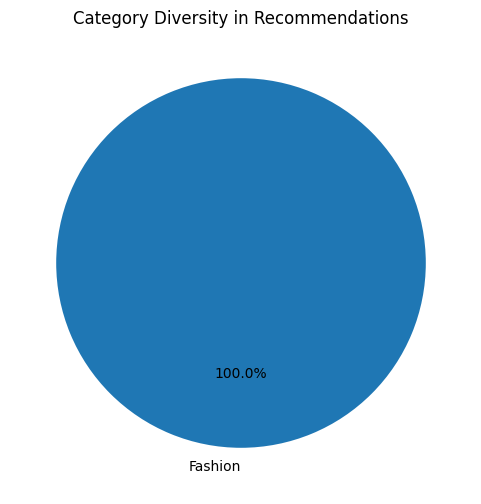

In [31]:
def plot_recommendation_diversity(recommendations):
    # Ensure we have a list of dicts
    if isinstance(recommendations, dict) and 'recommendations' in recommendations:
        recs_list = recommendations['recommendations']
    else:
        recs_list = recommendations

    recs_df = pd.DataFrame(recs_list)

    if 'category' not in recs_df.columns:
        print("No 'category' field in recommendations")
        return

    plt.figure(figsize=(6,6))
    recs_df['category'].value_counts().plot.pie(
        autopct='%1.1f%%', cmap='tab20', startangle=90
    )
    plt.title("Category Diversity in Recommendations")
    plt.ylabel("")
    plt.show()

recs = model.get_recommendations("ETP101701", top_n=10)
plot_recommendation_diversity(recs)

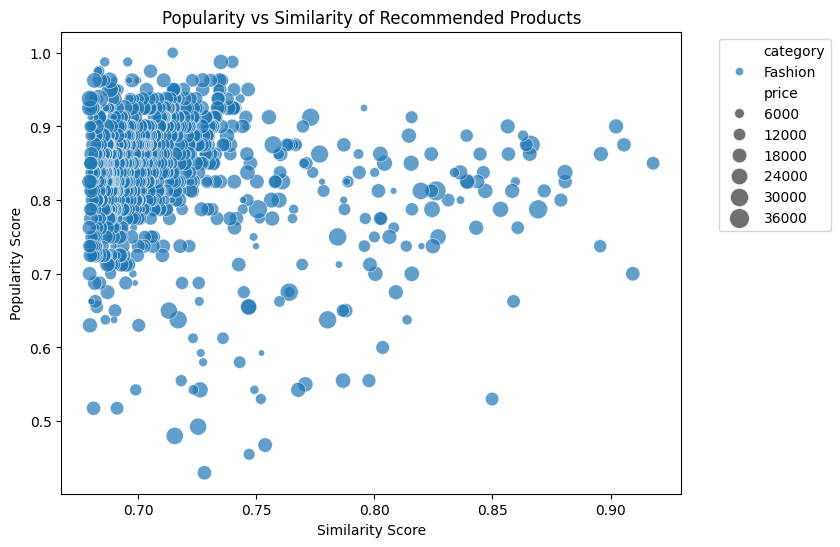

In [32]:
def plot_popularity_vs_similarity(recommendations):
    recs_df = pd.DataFrame(recommendations)
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=recs_df, x='similarity_score', y='popularity_score',
                    hue='category', size='price', sizes=(20,200), alpha=0.7)
    plt.title("Popularity vs Similarity of Recommended Products")
    plt.xlabel("Similarity Score")
    plt.ylabel("Popularity Score")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

recs = model.get_recommendations("ETP101701", top_n=1000)
plot_popularity_vs_similarity(recs)

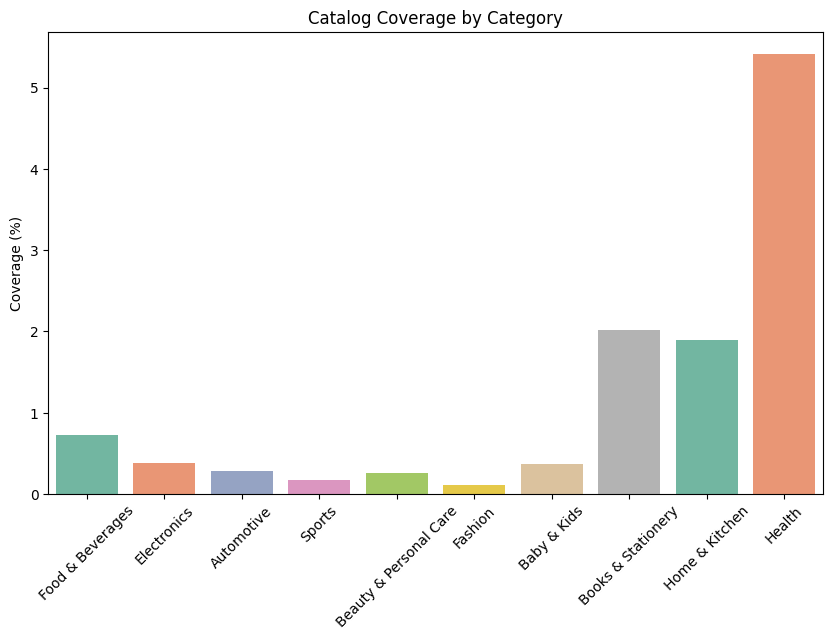

In [33]:
def plot_category_coverage(model, sample_size=10):
    categories = model.df['category'].unique()
    coverage = {}
    for cat in categories:
        sample = model.df[model.df['category'] == cat].sample(min(sample_size, len(model.df[model.df['category']==cat])), random_state=42)
        rec_ids = set()
        for pid in sample['product_id']:
            recs = model.get_recommendations(pid, top_n=5)
            for r in recs:
                rec_ids.add(r['product_id'])
        coverage[cat] = len(rec_ids) / len(model.df[model.df['category']==cat]) * 100

    plt.figure(figsize=(10,6))
    sns.barplot(x=list(coverage.keys()), y=list(coverage.values()), palette='Set2')
    plt.title("Catalog Coverage by Category")
    plt.ylabel("Coverage (%)")
    plt.xticks(rotation=45)
    plt.show()
plot_category_coverage(model)

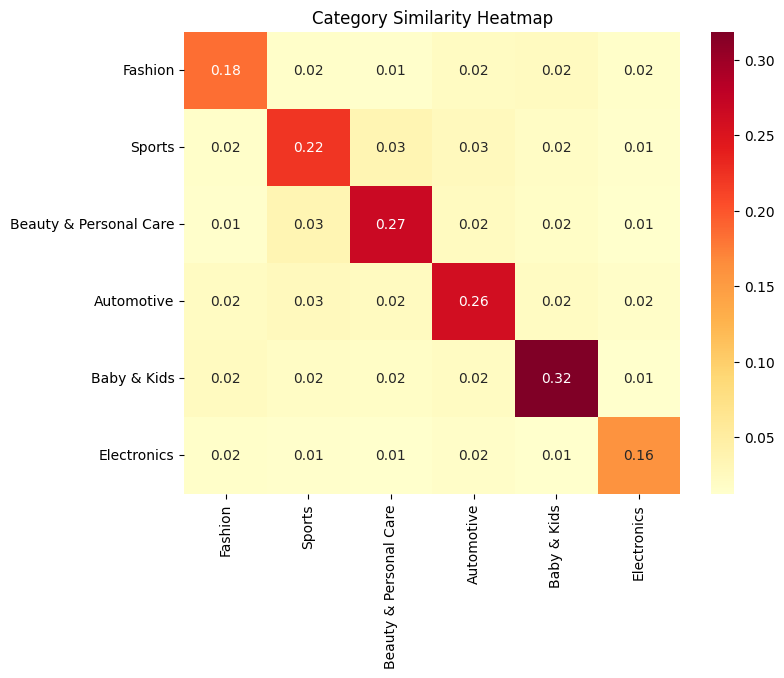

In [34]:
from sklearn.metrics.pairwise import cosine_similarity
def plot_category_similarity_heatmap(model, top_n=6):
    top_categories = model.df['category'].value_counts().head(top_n).index.tolist()
    similarity_matrix = np.zeros((len(top_categories), len(top_categories)))

    for i, cat1 in enumerate(top_categories):
        for j, cat2 in enumerate(top_categories):
            idx1 = model.df[model.df['category']==cat1].sample(50, random_state=42).index
            idx2 = model.df[model.df['category']==cat2].sample(50, random_state=42).index
            vec1 = model.tfidf_matrix[idx1]
            vec2 = model.tfidf_matrix[idx2]
            sims = cosine_similarity(vec1, vec2)
            similarity_matrix[i,j] = sims.mean()

    plt.figure(figsize=(8,6))
    sns.heatmap(similarity_matrix, annot=True, fmt=".2f",
                xticklabels=top_categories, yticklabels=top_categories, cmap="YlOrRd")
    plt.title("Category Similarity Heatmap")
    plt.show()
plot_category_similarity_heatmap(model)

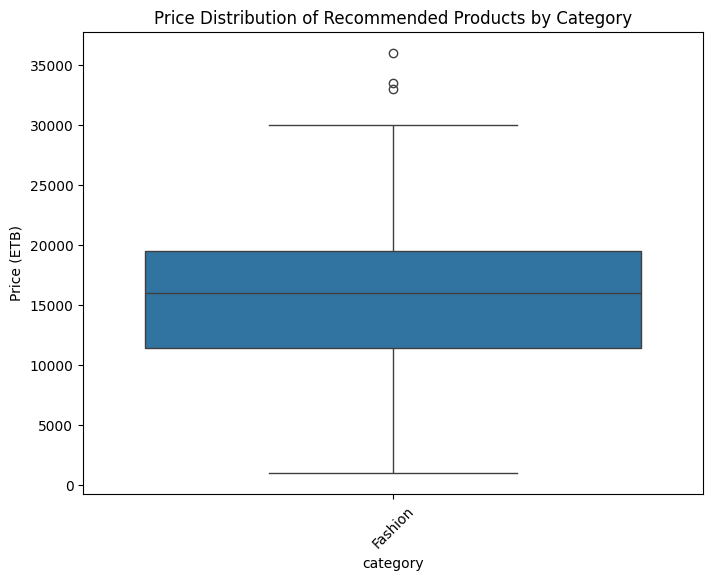

In [35]:
def plot_price_distribution(recommendations):
    recs_df = pd.DataFrame(recommendations)
    plt.figure(figsize=(8,6))
    sns.boxplot(data=recs_df, x='category', y='price')
    plt.title("Price Distribution of Recommended Products by Category")
    plt.ylabel("Price (ETB)")
    plt.xticks(rotation=45)
    plt.show()
recs = model.get_recommendations("ETP101701", top_n=100)
plot_price_distribution(recs)